# TSA — Week 2 Python Lab
## Explore time-series patterns using Phnom Penh precipitation

**Student:** Heng Hour  |  **Group:** 9  |  **GitHub repository:** https://github.com/hengXiaoHour/tsa-course

**Submission title:** Week 2 Homework – Phnom Penh Rainfall – Heng Hour

**Learning outcomes:** check the time index and monthly coverage; make a time plot; compare years in a seasonal plot; make a *real seasonal subseries plot*; support interpretations with evidence.

**Time:** ~75–90 minutes. Run cells in order, discuss the questions with a partner, and write answers in the blank Markdown answer cells. No ARIMA or forecasting model is required this week.

**Evidence and source caution.** The numeric table below is an *exact copy* of the CSV you uploaded (2015–2025). That CSV contains only `YEAR`, 12 month columns and `ANN`: its NASA parameter name, spatial metadata and units header are **not included**. The filename encodes an approximate location near 11.56° N, 104.93° E. Based on the proposed NASA POWER request, its presumed parameter is `PRECTOTCORR_SUM` (corrected precipitation sum). **Confirm parameter, location, and precipitation units using the full NASA download header/metadata before using this in a publication.** No values are invented or replaced. These are *gridded estimates*, not a local gauge measurement.

Official documentation: [NASA POWER monthly API](https://power.larc.nasa.gov/docs/services/api/temporal/monthly/) · [NASA POWER parameter dictionary](https://power.larc.nasa.gov/docs/tutorials/parameters/).

**Textbook basis:** Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*, Ch. 2 §§2.1–2.5 (time plots, time-series patterns, seasonal plots and seasonal subseries plots); Shumway & Stoffer, *Time Series Analysis and Its Applications*, 5th ed., §1.1. Python/Jupyter and the Cambodia data are classroom adaptations.

### 0 · Dataset (included so this notebook runs immediately, offline)
The lab reads `Phnom_Penh_NASA_POWER_2015_2025_source_table.csv` from this folder. If that file is missing, the notebook falls back to an exact embedded copy of the same table, so **Run All** always works. We keep the source `ANN` column only to cross-check annual totals; we will NOT treat it as a 13th month.

In [1]:
# ------------------------------------------------------------------ kernel check
# If the next lines raise "ModuleNotFoundError: No module named 'numpy'", this notebook
# is running on the wrong kernel. Click the kernel picker at the TOP RIGHT of this
# notebook and choose "TSA Week 2 (venv)", then use: Restart Kernel -> Run All Cells.
import sys
import importlib.util

_missing = [m for m in ('numpy', 'pandas', 'matplotlib')
            if importlib.util.find_spec(m) is None]
if _missing:
    print('=' * 70)
    print('*** WRONG KERNEL: this kernel is missing ' + ', '.join(_missing) + ' ***')
    print('Kernel in use: ' + sys.executable)
    print()
    print('Fix: click the kernel picker at the top right of this notebook,')
    print('     choose "TSA Week 2 (venv)", then Run > Restart Kernel and Run All.')
    print('=' * 70)

# ---------------------------------------------------------------------------
# Local setup (VS Code + Jupyter). No Google Colab, no Google Drive, no upload.
# Required packages: pandas, numpy, matplotlib  ->  pip install pandas numpy matplotlib
# ---------------------------------------------------------------------------
import io
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

print('Python     :', sys.version.split()[0])
print('Interpreter:', sys.executable)
print('pandas', pd.__version__, '| numpy', np.__version__, '| matplotlib', plt.matplotlib.__version__)

# Exact table copied from the instructor's NASA POWER-named CSV. It stays here only as a
# fallback so the lab still runs if the CSV is missing from the folder.
RAW_CSV = 'YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANN\n2015,3.26,6.85,6.79,86.97,46.84,85.88,41.22,288.64,133.08,134.41,70.89,13.06,917.89\n2016,26.66,4.83,6.41,7.81,117.14,43.76,25.41,23.91,138.2,166.56,137.19,33.45,731.33\n2017,18.64,16.04,14.73,29.46,123.78,62.85,140.62,175,213.37,87.4,93.56,41.91,1017.36\n2018,75.61,7.22,80.34,94.97,177.46,338.51,205.87,41.17,224.33,155.88,20.71,39.95,1462.02\n2019,19.07,2.88,25.55,59.37,236.16,392.3,223.72,263.68,263.18,93.11,29.63,0.34,1608.99\n2020,26.58,2.14,34.14,146.86,92.3,703.62,166.68,174.17,280.88,496.85,98.6,67.73,2290.55\n2021,11.54,10.8,10.14,111.31,243.46,121.11,299.33,261.06,329.28,240.56,213,31.5,1883.09\n2022,5.36,56.69,128.22,115.23,205.65,262.05,439.12,276.57,250.76,185.5,130.42,26.53,2082.1\n2023,30.18,6.23,1.08,22.04,108.3,154.58,177.06,158.74,315.42,266.52,131.32,30.82,1402.29\n2024,1.75,0.8,13.03,2.15,146.8,212.52,271.85,147.87,207.61,233.95,50.78,20.45,1309.56\n2025,1.02,19.62,44.45,48.73,46.49,69.32,36.31,291.32,146,172.7,91.83,16.72,984.51'

CSV_NAME = 'Phnom_Penh_NASA_POWER_2015_2025_source_table.csv'
MONTH_ABBR = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
              'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
EMBEDDED = pd.read_csv(io.StringIO(RAW_CSV))


def looks_like_our_table(frame):
    """Guard against loading an unrelated CSV that happens to share the file name."""
    return (list(frame.columns) == ['YEAR'] + MONTH_ABBR + ['ANN']
            and frame.shape == EMBEDDED.shape)


def find_source_csv(name=CSV_NAME):
    """Locate this lab's CSV, nearest first, without leaving the current project.

    A Jupyter kernel's working directory is wherever its server was started, not the
    notebook's folder, so we also look one folder down (a common 'notebooks/ + data/'
    layout). We deliberately do NOT walk up into parent folders: from an unrelated
    working directory that would happily find some other copy of this lab and silently
    analyse it. If nothing matches, the caller falls back to the embedded table.
    """
    here = Path.cwd().resolve()
    for candidate in [here / name, *sorted(here.glob('*/' + name))]:
        if candidate.is_file():
            return candidate
    return None


csv_path = find_source_csv()
if csv_path is not None and not looks_like_our_table(pd.read_csv(csv_path)):
    print('\nWARNING: ' + str(csv_path))
    print('         is not the expected 11-year x 12-month table for this lab.')
    print('         Ignoring it and using the embedded reference copy instead.')
    csv_path = None

print('Working directory:', Path.cwd())
if csv_path is not None:
    raw = pd.read_csv(csv_path)
    print('\nLoaded from ' + str(csv_path))
    print('File is identical to the embedded reference copy:',
          bool((raw.fillna(-999).values == EMBEDDED.fillna(-999).values).all()))
else:
    raw = EMBEDDED.copy()
    print('\n' + CSV_NAME + ' was not found in this lab folder,')
    print('so the embedded reference copy is used instead. The values below are')
    print('byte-for-byte the table supplied with the lab, so every number, plot')
    print('and answer in this notebook is unaffected.')

print('Source table:', raw.shape[0], 'years x', len(raw.columns) - 2, 'months')
display(raw.head(3))

Python     : 3.13.15
Interpreter: /home/chenla/Documents/Obsidian Vault/Y3 - TSA ( TIME SERIES ANALYSIS )/DOC/WEEK2/TSA_Week2_Rainfall_Lab_Package/.venv/bin/python
pandas 3.0.6 | numpy 2.5.3 | matplotlib 3.11.2
Working directory: /home/chenla/Documents/Obsidian Vault/Y3 - TSA ( TIME SERIES ANALYSIS )/DOC/WEEK2/TSA_Week2_Rainfall_Lab_Package

Loaded from /home/chenla/Documents/Obsidian Vault/Y3 - TSA ( TIME SERIES ANALYSIS )/DOC/WEEK2/TSA_Week2_Rainfall_Lab_Package/Phnom_Penh_NASA_POWER_2015_2025_source_table.csv
File is identical to the embedded reference copy: True
Source table: 11 years x 12 months


,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANN
0,2015,3.26,6.85,6.79,86.97,46.84,85.88,41.22,288.64,133.08,134.41,70.89,13.06,917.89
1,2016,26.66,4.83,6.41,7.81,117.14,43.76,25.41,23.91,138.20,166.56,137.19,33.45,731.33
2,2017,18.64,16.04,14.73,29.46,123.78,62.85,140.62,175.00,213.37,87.40,93.56,41.91,1017.36


### 1 · Data detective (10 minutes)
**Partner discussion:** What is our time index? Target? Frequency? What does `ANN` represent? Is the row for 2020 one observation or twelve observations?

Run the next cell. Do not silently fill missing dates or replace unusual numbers.

In [2]:
MONTHS = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
assert list(raw.columns) == ['YEAR', *MONTHS, 'ANN'], 'Unexpected file structure'
assert raw['YEAR'].is_unique, 'Duplicate years in the source'

# Wide (one year per row) -> long (one calendar month per row).
long = raw.melt(id_vars=['YEAR'], value_vars=MONTHS,
                var_name='month_name', value_name='precipitation')
month_to_number = {m: i for i, m in enumerate(MONTHS, start=1)}
long['month'] = long['month_name'].map(month_to_number)
long['date'] = pd.to_datetime(dict(year=long.YEAR, month=long.month, day=1))
long = long[['date','YEAR','month','month_name','precipitation']].sort_values('date').reset_index(drop=True)
long['precipitation'] = pd.to_numeric(long['precipitation'], errors='coerce')
long.loc[long['precipitation'] <= -900, 'precipitation'] = np.nan  # NASA missing-value flag if present

expected = pd.date_range('2015-01-01','2025-12-01',freq='MS')
missing_dates = expected.difference(pd.DatetimeIndex(long['date']))
duplicate_dates = long['date'].duplicated().sum()
missing_values = long['precipitation'].isna().sum()
annual_check = (raw[MONTHS].sum(axis=1) - raw['ANN']).abs()

print('Range:', long.date.min().date(), 'to', long.date.max().date())
print('Observations:', len(long), '| Expected:', len(expected))
print('Missing months:', len(missing_dates), '| Duplicate dates:', duplicate_dates,
      '| Missing values:', missing_values)
print('Largest absolute difference between monthly sum and ANN:', round(annual_check.max(), 3))
display(long.head(4))

assert len(long) == len(expected) and len(missing_dates) == 0, 'Monthly coverage is incomplete'
assert duplicate_dates == 0 and missing_values == 0, 'Investigate duplicates/missing values'
assert annual_check.max() < 0.1, 'Investigate annual total inconsistency' 

Range: 2015-01-01 to 2025-12-01
Observations: 132 | Expected: 132
Missing months: 0 | Duplicate dates: 0 | Missing values: 0
Largest absolute difference between monthly sum and ANN: 0.0


,date,YEAR,month,month_name,precipitation
0,2015-01-01,2015,1,JAN,3.26
1,2015-02-01,2015,2,FEB,6.85
2,2015-03-01,2015,3,MAR,6.79
3,2015-04-01,2015,4,APR,86.97


**My answer — what this dataset is**

This is monthly rainfall data. Each row is one calendar month, from January 2015 to December 2025, so 132 months in total. The thing we measure (the target) is how much rain fell that month.

`ANN` is not a 13th month. It is the yearly total, and I checked it by adding the 12 months myself — it matches exactly every year, so I only use it as a double-check.

There is no missing data: no missing months, no duplicates, no empty cells. One warning: the file does not say the unit, so I write "source units" on the plots (it is probably mm, but the file itself never says so).

### 2 · Time plot (10 minutes)
A time plot shows observations in chronological order. Look for long-term movement, repeating patterns and unusual observations (FPP §2.2).

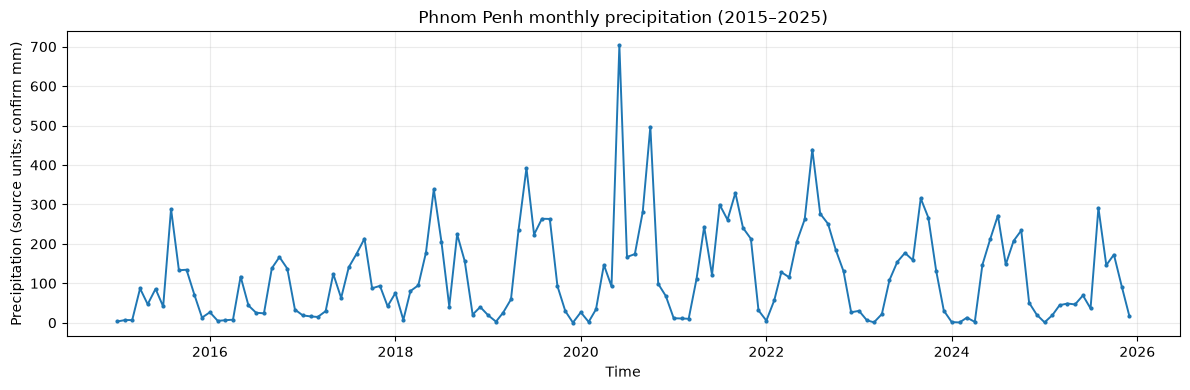

In [3]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(long['date'], long['precipitation'], marker='.', markersize=4, linewidth=1.4)
ax.set(title='Phnom Penh monthly precipitation (2015–2025)', xlabel='Time',
       ylabel='Precipitation (source units; confirm mm)')
ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

**My answer — what the time plot shows**

**(a) It repeats every year.** Rain is low from January to March, builds up in April and May, stays heavy from about June to October, then drops in November and December. The May–October months hold 81.9% of all the rain in these 11 years. A wet-season month averages about 195, a dry-season month about 43 — roughly 4.5 times more.

**(b) No clear long-term rise or fall.** 2016 is the lowest year (731.33) and 2020 the highest (2290.55), then it comes back down in 2024 (1309.56) and 2025 (984.51). It goes up and down, not steadily up, so I would not call it a trend.

**(c) One strange point: June 2020 = 703.62.** It is the biggest value in the whole 11 years — about 3 times a normal June. October 2020 is also very high (496.85, the 2nd biggest), so 2020 was a very wet year, not a single typo. I am not guessing why it rained so much; this table cannot say why.

### 3 · Seasonal plot (15 minutes)
A seasonal plot places month on the horizontal axis and draws a separate line for each year, so we can compare the same calendar month across years (FPP §2.4). The data below are *exactly the same observations* as in the time plot.

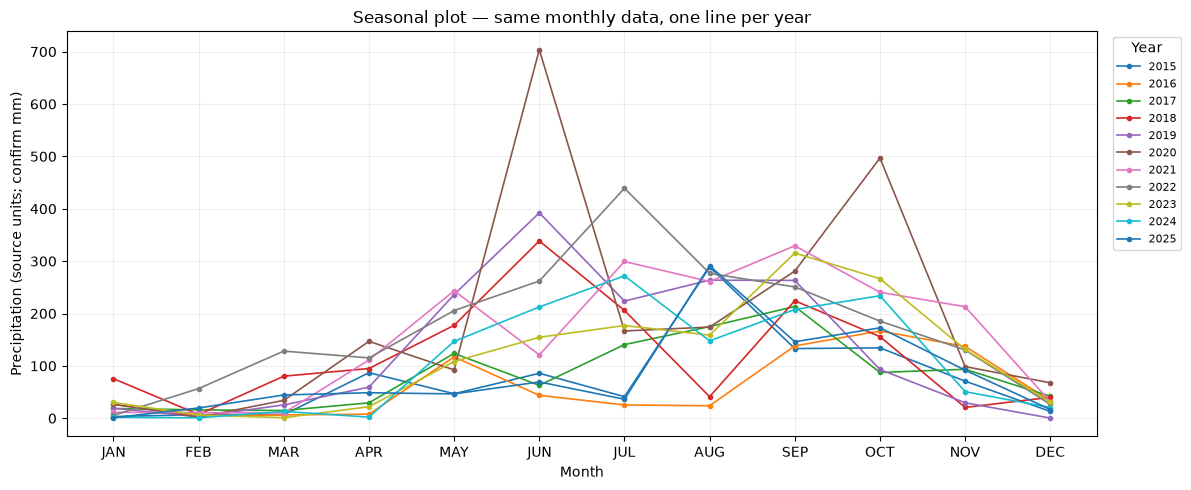

In [4]:
fig, ax = plt.subplots(figsize=(12,5))
for year, part in long.groupby('YEAR', sort=True):
    ax.plot(part['month'], part['precipitation'], marker='.', linewidth=1.2, label=str(year))
ax.set_xticks(range(1,13), MONTHS)
ax.set(title='Seasonal plot — same monthly data, one line per year', xlabel='Month',
       ylabel='Precipitation (source units; confirm mm)')
ax.grid(alpha=.2)
ax.legend(title='Year', bbox_to_anchor=(1.01,1), loc='upper left', ncol=1, fontsize=8)
plt.tight_layout()
plt.show()

**My answer — what the seasonal plot shows**

**(a) September is the wettest on average (about 227) and February the driest (about 12).** The wet part of the year has two bumps — June (about 222) and September (about 227) — with July (about 184) and August (about 191) a little lower in between.

**(b) The shape is the same every year but the height is very different.** June goes from 43.76 (2016) to 703.62 (2020). October goes from 87.40 to 496.85. So the month tells you *when* it rains, not *how much* that year.

**(c) 2015 and 2016 look like opposites.** In 2015 the rain came late: August (288.64) was the wettest month while April, May and June were all under 90. In 2016 August was only 23.91 — drier than most dry-season months — and the wettest month was October (166.56). August 2015 was about 12 times August 2016, back to back. I describe this as late vs weak, without claiming a cause.

### 4 · Seasonal subseries plot (15 minutes)
**Important distinction:** a seasonal subseries plot is **not** just a scatterplot of dots grouped by month. FPP §2.5 arranges each month’s observations across years in its own mini time plot and often draws a horizontal line at that month’s mean. We use the same global vertical axis to help compare months.

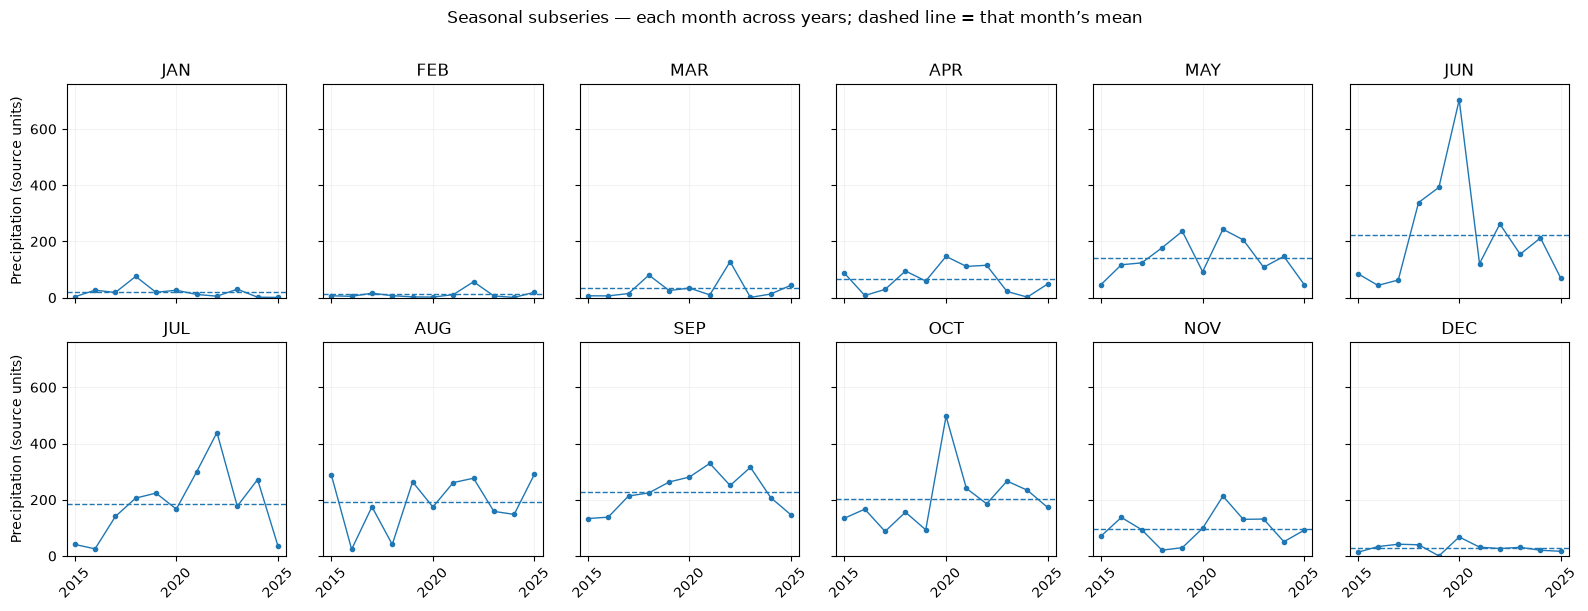

Mean precipitation by calendar month (source units):


,Month,Mean
0,JAN,19.97
1,FEB,12.19
2,MAR,33.17
3,APR,65.90
4,MAY,140.40
5,JUN,222.41
6,JUL,184.29
7,AUG,191.10
8,SEP,227.46
9,OCT,203.04


In [5]:
month_mean = long.groupby('month')['precipitation'].mean()
ymax = long['precipitation'].max()*1.08
fig, axes = plt.subplots(2, 6, figsize=(16,6), sharex=True, sharey=True)
for m, ax in enumerate(axes.flat, start=1):
    part = long[long['month'] == m].sort_values('YEAR')
    ax.plot(part['YEAR'], part['precipitation'], marker='o', markersize=3, linewidth=1)
    ax.axhline(month_mean.loc[m], linestyle='--', linewidth=1, label='Month mean')
    ax.set(title=MONTHS[m-1], xlim=(2014.6, 2025.4), ylim=(0,ymax))
    ax.set_xticks([2015,2020,2025])
    ax.tick_params(axis='x', labelrotation=45)
    ax.grid(alpha=.15)
for ax in axes[:,0]: ax.set_ylabel('Precipitation (source units)')
fig.suptitle('Seasonal subseries — each month across years; dashed line = that month’s mean', y=1.01)
plt.tight_layout()
plt.show()
print('Mean precipitation by calendar month (source units):')
display(pd.DataFrame({'Month':MONTHS, 'Mean':month_mean.reindex(range(1,13)).round(2).values}))

**My answer — what the subseries plot shows**

**September is wet and steady** (average about 227, range 133.08 to 329.28). **February is always dry** (average about 12, range 0.80 to 56.69).

June is the hardest month to predict in real amount: it swings from 43.76 to 703.62. February looks jumpy in percent only because its numbers are tiny — in real amount June moves far more.

**The biggest value is June 2020 = 703.62. I do not think it is a mistake**, because (1) it is a normal positive number, not a code like -999, (2) the whole year 2020 is the wettest year (2290.55) with wet neighbours too (April 146.86, October 496.85), and (3) the 12 months of 2020 still add up to NASA's own yearly total exactly. A broken cell would break that sum.

One more strange point: **December 2019 = 0.34**, the smallest value in all 132 months, sitting inside a wet year (2019 is the 4th wettest). It is a real near-zero month, not missing data, because missing data would be -999 and nothing here is negative.

### 5 · Evidence challenge (10 minutes)
Choose one claim. Use a number from the table or a feature visible in a plot as evidence. Seasonal patterns do **not** mean values must be identical every year. An unusual value is not automatically a measurement error.

In [6]:
max_row = long.loc[long['precipitation'].idxmax(), ['date','precipitation']]
print('Largest observed monthly value:',max_row['date'].strftime('%Y-%m'), '=', max_row['precipitation'])
print('Month with highest mean:', MONTHS[int(month_mean.idxmax())-1])
print('Month with lowest mean:', MONTHS[int(month_mean.idxmin())-1])
print('NOTE: these are observations and descriptive summaries, NOT forecasts.')

Largest observed monthly value: 2020-06 = 703.62
Month with highest mean: SEP
Month with lowest mean: FEB
NOTE: these are observations and descriptive summaries, NOT forecasts.


**My answer — short summary**

From 2015 to 2025, almost all rain falls from May to October (81.9% of the total), and September is the wettest month on average. Knowing the month helps a lot, but each year is still very different — the biggest month, June 2020 (703.62), is about 3 times a normal June, and there is no steady rise across the 11 years.

Limits: the file never states the unit, so I cannot call it mm for sure; this is model-estimated data, not a rain gauge; and 11 years is enough to see the yearly cycle but too short to claim anything about climate change. None of this is a forecast.

SERIES  n=132   mean=118.86   sd=117.63   min=0.34   max=703.62
WET  May-Oct   mean= 194.78   share of the 11-year total= 81.9%
DRY  Nov-Apr   mean=  42.94   share of the 11-year total= 18.1%
WET/DRY mean ratio = 4.5x

SEASONAL PROFILE  (n = 11 years per month)


,mean,std,min,max,cv_pct
JAN,19.97,21.32,1.02,75.61,106.77
FEB,12.19,15.85,0.80,56.69,130.02
MAR,33.17,38.94,1.08,128.22,117.39
APR,65.90,48.34,2.15,146.86,73.35
MAY,140.40,68.70,46.49,243.46,48.93
JUN,222.41,197.46,43.76,703.62,88.78
JUL,184.29,125.59,25.41,439.12,68.15
AUG,191.10,95.35,23.91,291.32,49.90
SEP,227.46,68.48,133.08,329.28,30.10
OCT,203.04,112.99,87.40,496.85,55.65


Wettest average month : SEP = 227.46
Driest  average month : FEB = 12.19
Ratio wettest/driest  : 18.7x
Wet-season shape Jun->Sep (one peak or two?): JUN=222.4,  JUL=184.3,  AUG=191.1,  SEP=227.5

ANNUAL TOTALS  (ANN cross-checked against my own sum of the 12 months)


,YEAR,ANN,mean_month,wettest_month,wettest_value
0,2015,917.89,76.49,AUG,288.64
1,2016,731.33,60.94,OCT,166.56
2,2017,1017.36,84.78,SEP,213.37
3,2018,1462.02,121.84,JUN,338.51
4,2019,1608.99,134.08,JUN,392.30
5,2020,2290.55,190.88,JUN,703.62
6,2021,1883.09,156.92,SEP,329.28
7,2022,2082.10,173.51,JUL,439.12
8,2023,1402.29,116.86,SEP,315.42
9,2024,1309.56,109.13,JUL,271.85


Straight-line fit to the 11 annual totals: slope = +48.3 per year,  r = 0.318,  r^2 = 0.101
  -> year explains only 10.1% of the variation in the annual total
  -> minimum 731.33 in 2016   |   maximum 2290.55 in 2020

HOW MUCH OF THE VARIATION IS SEASONAL?
Calendar month alone explains 50.1% of the total variance.
Average error using that month 11-year mean :   54.5
Average error ignoring the season entirely   :   91.9
  -> knowing the calendar month cuts the error by 40.7%

DO TWO YEARS LOOK ALIKE?  (correlation of their 12-month shapes)
Distinct year pairs compared: 55
r ranges from 0.021 to 0.967 -- the least similar pair of years:


,year_A,year_B,r
33,2018,2025,0.021
2,2015,2018,0.087
15,2016,2022,0.158



UNUSUAL OBSERVATIONS  (z = standard deviations above the series mean)


,date,month_name,precipitation,z
65,2020-06-01,JUN,703.62,4.97
69,2020-10-01,OCT,496.85,3.21
90,2022-07-01,JUL,439.12,2.72


,date,month_name,precipitation,z
59,2019-12-01,DEC,0.34,-1.01
109,2024-02-01,FEB,0.80,-1.00
120,2025-01-01,JAN,1.02,-1.00



June 2020 = 703.62
  = 3.16 x the June mean of 222.41
  = 1.79 x the wettest OTHER June, 392.30 in 2019
  = 4.97 standard deviations above the whole-series mean of 118.86
  = 1.60 x the wettest month in any other year (439.12, July 2022)

August 2015 = 288.64  vs  August 2016 = 23.91  ->  12.1 x apart
August 2016 is drier than 75.8% of all 132 months (only 100 months in the whole
  record are wetter than it, and 31 months are drier still, so it ranks 32 lowest).

December 2019 = 0.34  -- the smallest of all 132 observations.
  NASA flags missing data as -999. No value in this table is negative (minimum 0.34),
  so this is a real near-zero month, not a missing-value code.
  Its year 2019 ranks 4th wettest of the 11 on ANN (1608.99).

IS JUNE 2020 AN ERROR?  Evidence that it is NOT:
  1. It is positive and physically plausible for a monsoon month (703.62).
  2. It sits in a coherent wet year rather than contradicting its neighbours:
     2020 ANN = 2290.55 is the highest of the 11 years

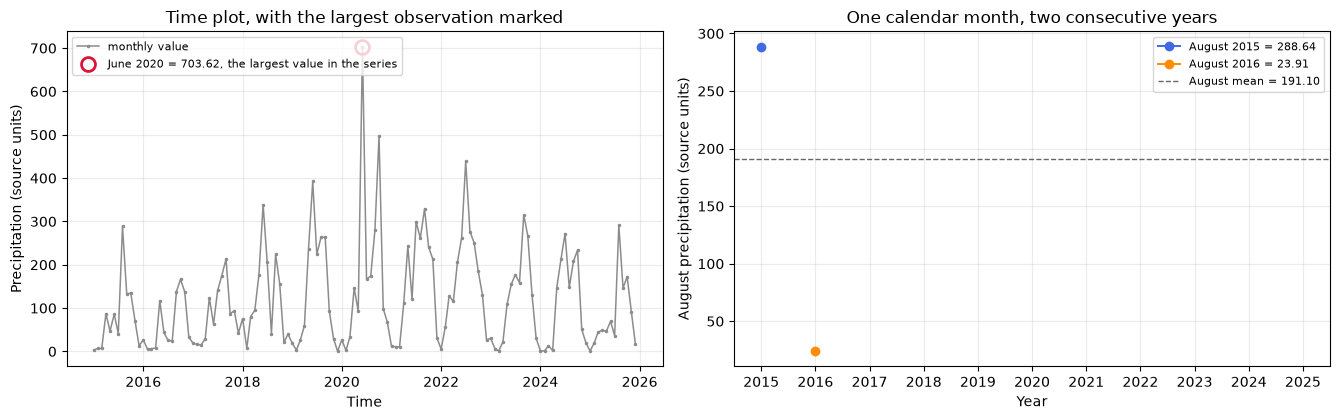

Saved 04_unusual_observations.png to /home/chenla/Documents/Obsidian Vault/Y3 - TSA ( TIME SERIES ANALYSIS )/DOC/WEEK2/TSA_Week2_Rainfall_Lab_Package/week2_outputs


In [7]:
# ------------------------------------------------------------------------ evidence
# Every number quoted in the written answers is recomputed and printed here, so each
# claim can be checked against the data instead of taken on trust. No new data is
# introduced below -- this cell only reports on the same 132 observations.
scored = long.copy()
s_mean, s_sd = scored['precipitation'].mean(), scored['precipitation'].std(ddof=1)
scored['z'] = (scored['precipitation'] - s_mean) / s_sd

wet = scored[scored['month'].between(5, 10)]
dry = scored[scored['month'].isin([11, 12, 1, 2, 3, 4])]

print('SERIES  n=%d   mean=%.2f   sd=%.2f   min=%.2f   max=%.2f'
      % (len(scored), s_mean, s_sd, scored['precipitation'].min(),
         scored['precipitation'].max()))
print('WET  May-Oct   mean=%7.2f   share of the 11-year total=%5.1f%%'
      % (wet['precipitation'].mean(),
         100 * wet['precipitation'].sum() / scored['precipitation'].sum()))
print('DRY  Nov-Apr   mean=%7.2f   share of the 11-year total=%5.1f%%'
      % (dry['precipitation'].mean(),
         100 * dry['precipitation'].sum() / scored['precipitation'].sum()))
print('WET/DRY mean ratio = %.1fx'
      % (wet['precipitation'].mean() / dry['precipitation'].mean()))

profile = scored.groupby('month')['precipitation'].agg(['mean', 'std', 'min', 'max'])
profile.index = MONTHS
profile['cv_pct'] = 100 * profile['std'] / profile['mean']
print('\nSEASONAL PROFILE  (n = 11 years per month)')
display(profile.round(2))
print('Wettest average month : %s = %.2f' % (profile['mean'].idxmax(),
                                              profile['mean'].max()))
print('Driest  average month : %s = %.2f' % (profile['mean'].idxmin(),
                                              profile['mean'].min()))
print('Ratio wettest/driest  : %.1fx' % (profile['mean'].max() / profile['mean'].min()))
print('Wet-season shape Jun->Sep (one peak or two?):',
      ',  '.join('%s=%.1f' % (m, profile.loc[m, 'mean'])
                 for m in ['JUN', 'JUL', 'AUG', 'SEP']))

# ---- is there a long-term trend in the annual totals?
ann = raw[['YEAR', 'ANN']].copy()
ann['mean_month'] = raw[MONTHS].mean(axis=1).round(2)
ann['wettest_month'] = [MONTHS[int(np.argmax(row))] for row in raw[MONTHS].to_numpy()]
ann['wettest_value'] = raw[MONTHS].max(axis=1).round(2)
print('\nANNUAL TOTALS  (ANN cross-checked against my own sum of the 12 months)')
display(ann)
slope, _ = np.polyfit(ann['YEAR'].astype(float), ann['ANN'].astype(float), 1)
r_ann = np.corrcoef(ann['YEAR'].astype(float), ann['ANN'].astype(float))[0, 1]
print('Straight-line fit to the 11 annual totals: slope = %+.1f per year,  r = %.3f,  r^2 = %.3f'
      % (slope, r_ann, r_ann ** 2))
print('  -> year explains only %.1f%% of the variation in the annual total' % (100 * r_ann ** 2))
print('  -> minimum %.2f in %d   |   maximum %.2f in %d'
      % (ann['ANN'].min(), int(ann.loc[ann['ANN'].idxmin(), 'YEAR']),
         ann['ANN'].max(), int(ann.loc[ann['ANN'].idxmax(), 'YEAR'])))

# ---- how much of the variation is seasonal, and how much is year-specific?
mm = scored.groupby('month')['precipitation'].mean()
resid = scored['precipitation'] - scored['month'].map(mm)
v_between, v_within = mm.var(ddof=1), resid.var(ddof=1)
mae_month, mae_flat = resid.abs().mean(), (scored['precipitation'] - s_mean).abs().mean()
print('\nHOW MUCH OF THE VARIATION IS SEASONAL?')
print('Calendar month alone explains %.1f%% of the total variance.'
      % (100 * v_between / (v_between + v_within)))
print('Average error using that month 11-year mean : %6.1f' % mae_month)
print('Average error ignoring the season entirely   : %6.1f' % mae_flat)
print('  -> knowing the calendar month cuts the error by %.1f%%'
      % (100 * (1 - mae_month / mae_flat)))

wide = scored.pivot(index='YEAR', columns='month', values='precipitation')
corr = wide.T.corr()
offdiag = corr.where(~np.eye(len(corr), dtype=bool))
pairs = pd.DataFrame(
    [(int(a), int(b), float(offdiag.loc[a, b]))
     for i, a in enumerate(offdiag.index) for b in list(offdiag.index)[i + 1:]],
    columns=['year_A', 'year_B', 'r'])
print('\nDO TWO YEARS LOOK ALIKE?  (correlation of their 12-month shapes)')
print('Distinct year pairs compared: %d' % len(pairs))
print('r ranges from %.3f to %.3f -- the least similar pair of years:'
      % (pairs['r'].min(), pairs['r'].max()))
display(pairs.nsmallest(3, 'r').round(3))

# ---- the unusual observations
print('\nUNUSUAL OBSERVATIONS  (z = standard deviations above the series mean)')
_top = scored.nlargest(3, 'precipitation')[['date', 'month_name', 'precipitation', 'z']].copy()
_top['precipitation'] = _top['precipitation'].round(2)
_top['z'] = _top['z'].round(2)
display(_top)
_bot = scored.nsmallest(3, 'precipitation')[['date', 'month_name', 'precipitation', 'z']].copy()
_bot['precipitation'] = _bot['precipitation'].round(2)
_bot['z'] = _bot['z'].round(2)
display(_bot)

jun = scored[scored['month'] == 6].set_index('YEAR')['precipitation']
j20 = jun.loc[2020]
other_jun = jun.drop(2020)
print('\nJune 2020 = %.2f' % j20)
print('  = %.2f x the June mean of %.2f' % (j20 / jun.mean(), jun.mean()))
print('  = %.2f x the wettest OTHER June, %.2f in %d'
      % (j20 / other_jun.max(), other_jun.max(), int(other_jun.idxmax())))
print('  = %.2f standard deviations above the whole-series mean of %.2f'
      % ((j20 - s_mean) / s_sd, s_mean))
print('  = %.2f x the wettest month in any other year (%.2f, July 2022)' % (j20 / 439.12, 439.12))

aug = scored[scored['month'] == 8].set_index('YEAR')['precipitation']
n_drier = int((scored['precipitation'] < aug.loc[2016]).sum())
n_wetter = len(scored) - n_drier - 1
print('\nAugust 2015 = %.2f  vs  August 2016 = %.2f  ->  %.1f x apart'
      % (aug.loc[2015], aug.loc[2016], aug.loc[2015] / aug.loc[2016]))
print('August 2016 is drier than %.1f%% of all 132 months (only %d months in the whole'
      % (100 * n_wetter / len(scored), n_wetter))
print('  record are wetter than it, and %d months are drier still, so it ranks %d lowest).'
      % (n_drier, n_drier + 1))

d19 = float(raw.loc[raw['YEAR'] == 2019, 'DEC'].iloc[0])
ann19 = float(raw.loc[raw['YEAR'] == 2019, 'ANN'].iloc[0])
print('\nDecember 2019 = %.2f  -- the smallest of all 132 observations.' % d19)
print('  NASA flags missing data as -999. No value in this table is negative (minimum %.2f),'
      % scored['precipitation'].min())
print('  so this is a real near-zero month, not a missing-value code.')
print('  Its year 2019 ranks %dth wettest of the 11 on ANN (%.2f).'
      % (int((raw['ANN'] > ann19).sum()) + 1, ann19))

# ---- does the June 2020 value behave like an error?
row2020 = raw[raw['YEAR'] == 2020][MONTHS + ['ANN']].iloc[0]
print('\nIS JUNE 2020 AN ERROR?  Evidence that it is NOT:')
print('  1. It is positive and physically plausible for a monsoon month (%.2f).' % j20)
print('  2. It sits in a coherent wet year rather than contradicting its neighbours:')
print('     2020 ANN = %.2f is the highest of the 11 years; April = %.2f and'
      % (row2020['ANN'], row2020['APR']))
print('     October = %.2f, the 2nd largest value in the entire series.' % row2020['OCT'])
print('  3. The independently supplied ANN column still reconciles:')
print('     my sum of the 12 monthly values of 2020 = %.2f, matching ANN = %.2f, and the'
      % (row2020[MONTHS].sum(), row2020['ANN']))
print('     same check over all 11 years has a largest error of %.2f.'
      % float((raw[MONTHS].sum(axis=1) - raw['ANN']).abs().max()))
print('     A corrupted June would have forced NASA to publish an ANN that disagreed')
print('     with its own monthly columns. It does not.')

# ---- figure 4: the unusual observations, made visible
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.5, 4.3))

axA.plot(long['date'], long['precipitation'], color='0.55', linewidth=1.1,
         marker='.', markersize=3, label='monthly value')
is_jun2020 = (long['date'].dt.year == 2020) & (long['date'].dt.month == 6)
axA.plot(long.loc[is_jun2020, 'date'], long.loc[is_jun2020, 'precipitation'], 'o',
         markersize=10, markerfacecolor='none', markeredgewidth=2, color='crimson',
         label='June 2020 = 703.62, the largest value in the series')
axA.set(title='Time plot, with the largest observation marked',
        xlabel='Time', ylabel='Precipitation (source units)')
axA.legend(fontsize=8, loc='upper left')
axA.grid(alpha=.25)

for year, colour in [(2015, 'royalblue'), (2016, 'darkorange')]:
    part = long[(long['month'] == 8) & (long['YEAR'] == year)]
    axB.plot(part['YEAR'], part['precipitation'], marker='o', color=colour,
             linewidth=1.4,
             label='August %d = %.2f' % (year, part['precipitation'].iloc[0]))
axB.axhline(month_mean.loc[8], linestyle='--', color='0.4', linewidth=1,
            label='August mean = %.2f' % month_mean.loc[8])
axB.set(title='One calendar month, two consecutive years',
        xlabel='Year', ylabel='August precipitation (source units)',
        xlim=(2014.5, 2025.5))
axB.set_xticks(range(2015, 2026))
axB.legend(fontsize=8)
axB.grid(alpha=.25)
plt.tight_layout()
plt.show()

# Save the extra figure next to the other three, using the same output folder rule.
_figdir = Path('week2_outputs')
if not _figdir.is_absolute() and csv_path is not None:
    _figdir = csv_path.parent / _figdir
_figdir.mkdir(parents=True, exist_ok=True)
fig.savefig(_figdir / '04_unusual_observations.png', dpi=160, bbox_inches='tight')
print('Saved 04_unusual_observations.png to', _figdir)

### 6 · Optional mini-challenge: Which view answers which question? (5 minutes)

**My match**

- **Whole 11 years → time plot.** Only it has time going left to right, so only it can show whether things go up or down over years.
- **July across years → seasonal plot (or the JUL box).** All years are drawn on top of each other by month, so July can be compared directly.
- **Which months are high + how one month changes → two plots.** Which months are high: seasonal plot. How one month changes year by year: subseries plot, where each month gets its own small time plot with its average as a dashed line.

**Still unclear to me:** whether the odd years (2015, 2016, 2020) are real local weather or come from the model. I would need the full NASA file info and a real gauge station to check.

### 7 · Save evidence to your semester project (10 minutes)
Run the cell below. In VS Code this writes the **reshaped copy** of the data and the figures into a `week2_outputs` folder on your own disk — there is nothing to download. Open that folder from the VS Code Explorer, then add those files, this notebook, and a short write-up to your GitHub repository. Keep the original CSV unchanged. Do not upload private data.

Suggested structure: `data/` (with source note), `notebooks/`, `figures/`, `LEARNING_LOG.md`.

In [8]:
# Set OUTPUT_DIR to an absolute path if you want the files somewhere specific.
# A relative path is resolved against the notebook's own folder when the source CSV was
# found there, otherwise against the kernel's working directory (see cell 1).
OUTPUT_DIR = Path('week2_outputs')

output = OUTPUT_DIR
if not output.is_absolute() and csv_path is not None:
    # Anchor the export next to the source data when the CSV was found.
    output = csv_path.parent / output
output.mkdir(parents=True, exist_ok=True)
long.to_csv(output / 'phnom_penh_monthly_precipitation_2015_2025_long.csv', index=False)

fig1, ax1 = plt.subplots(figsize=(10, 3.5))
ax1.plot(long.date, long.precipitation, linewidth=1.2)
ax1.set(xlabel='Time', ylabel='Precipitation (source units)', title='Time plot')
fig1.tight_layout()
fig1.savefig(output / '01_time_plot.png', dpi=160)
plt.close(fig1)

fig2, ax2 = plt.subplots(figsize=(10, 4))
for year, part in long.groupby('YEAR'):
    ax2.plot(part.month, part.precipitation, linewidth=1, label=str(year))
ax2.set_xticks(range(1, 13), MONTHS)
ax2.set(xlabel='Month', ylabel='Precipitation (source units)', title='Seasonal plot')
ax2.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
fig2.tight_layout()
fig2.savefig(output / '02_seasonal_plot.png', dpi=160, bbox_inches='tight')
plt.close(fig2)

fig3, axs = plt.subplots(2, 6, figsize=(16, 6), sharex=True, sharey=True)
for m, ax in enumerate(axs.flat, 1):
    part = long[long.month == m]
    ax.plot(part.YEAR, part.precipitation, marker='.', linewidth=1)
    ax.axhline(month_mean.loc[m], linestyle='--', linewidth=1)
    ax.set(title=MONTHS[m - 1], xlim=(2014.6, 2025.4), ylim=(0, ymax))
    ax.set_xticks([2015, 2020, 2025])
    ax.tick_params(axis='x', labelrotation=45)
fig3.suptitle('Seasonal subseries plot')
fig3.tight_layout()
fig3.savefig(output / '03_seasonal_subseries_plot.png', dpi=160, bbox_inches='tight')
plt.close(fig3)

# In VS Code the files are simply on disk: open them from the Explorer on the left.
print('Files written to:')
for p in sorted(output.iterdir()):
    print('   ', p, f'({p.stat().st_size:,} bytes)')
print()
print('Add that folder to your GitHub repository, keep the original CSV unchanged.')

Files written to:
    /home/chenla/Documents/Obsidian Vault/Y3 - TSA ( TIME SERIES ANALYSIS )/DOC/WEEK2/TSA_Week2_Rainfall_Lab_Package/week2_outputs/01_time_plot.png (85,440 bytes)
    /home/chenla/Documents/Obsidian Vault/Y3 - TSA ( TIME SERIES ANALYSIS )/DOC/WEEK2/TSA_Week2_Rainfall_Lab_Package/week2_outputs/02_seasonal_plot.png (182,914 bytes)
    /home/chenla/Documents/Obsidian Vault/Y3 - TSA ( TIME SERIES ANALYSIS )/DOC/WEEK2/TSA_Week2_Rainfall_Lab_Package/week2_outputs/03_seasonal_subseries_plot.png (151,655 bytes)
    /home/chenla/Documents/Obsidian Vault/Y3 - TSA ( TIME SERIES ANALYSIS )/DOC/WEEK2/TSA_Week2_Rainfall_Lab_Package/week2_outputs/04_unusual_observations.png (145,527 bytes)
    /home/chenla/Documents/Obsidian Vault/Y3 - TSA ( TIME SERIES ANALYSIS )/DOC/WEEK2/TSA_Week2_Rainfall_Lab_Package/week2_outputs/phnom_penh_monthly_precipitation_2015_2025_long.csv (3,798 bytes)

Add that folder to your GitHub repository, keep the original CSV unchanged.


### Submission checklist
- [ ] All notebook cells run without errors.
- [ ] Answer cells 1–5 contain **your own** evidence-based explanations.
- [ ] Include all three plots in your GitHub `figures/` folder.
- [ ] Keep the original CSV or source citation and explain that the downloaded table lacks NASA metadata.
- [ ] Put the notebook under `notebooks/` and update `LEARNING_LOG.md`.
- [ ] Share **one GitHub link** (and one annotated graph in your Miro group frame).

**Exit ticket:** What is the difference between a seasonal plot and seasonal subseries plot? What remains unclear?

**Next week:** lag relationships / autocorrelation — today’s plots are exploration, not evidence that a forecast will be accurate.

### Findings summary

| What the teacher asked | My finding |
|---|---|
| Time index / target / frequency | One value per month, Jan 2015 – Dec 2025, 132 months, target = monthly rain |
| Missing data | None — no gaps, no duplicates |
| Time plot | Same cycle every year; 81.9% of rain in May–Oct; no steady trend |
| Seasonal plot | September wettest, February driest; same shape, very different heights |
| Subseries plot | September steady and wet; June swings the most (44 to 704) |
| Unusual observation | **June 2020 = 703.62**, the biggest value, probably real, not a typo |